<a href="https://colab.research.google.com/github/miki287/deeplearning-chapter2_colab/blob/main/DeepLearning_Chapter2_summary.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 2章 パーセプトロン

##2.1 パーセプトロンとは
パーセプトロン(Perceptron)は、AIやディープラーニングの基礎となる、もっともシンプルな人工ニューロンのモデルである。\
複数の入力を受け取り、それぞれの重要度(__重み__)を足し合わせて合計し、基準値(__閾値__)を超えたら『1』、越えなければ『0』を出力する仕組みである。

2入力のパーセプトロンの模式図は以下のようになる。

<div align="center">
  <img src="https://github.com/miki287/deeplearning-chapter2_colab/blob/58c5114f42e70c033e4e9f8f125a9aa4bdd8433e/2_perceptron.png" width="60%">
  <p>図1: 2入力のパーセプトロンの模式図</p>
</div>

上図より閾値を$θ$とおくと、パーセプトロンの出力$y$は以下のように表される。
$$
y = \begin{cases}
0 & (w_1 x_1 + w_2 x_2 \le \theta) \\
1 & (w_1 x_1 + w_2 x_2 > \theta)
\end{cases}\tag{1}
$$

$w_1$、$w_2$で表される重みが大きければ大きいほど、その重みに対応する信号の重要度が高くなっている。

##2.2 論理回路の実装
次に、パーセプトロンを使って、論理回路の実装を行う

###2.2.1 ANDゲート
ANDゲートの真理値表は以下のようになる。表の入力($x_1$,$x_2$)、出力($y$)は、図1と対応している。

表1 ANDゲートの真理値表
| $x_1$ | $x_2$ | $y$ |
| :---: | :---: | :---: |
| 0 | 0 | 0 |
| 0 | 1 | 0 |
| 1 | 0 | 0 |
| 1 | 1 | 1 |

式(1)から、$(w_1,w_2,\theta) = (0.5,0.5,0.7)$と設定すれば、表1のように動作させることができる。\
これをPythonで実装すると以下のようになる。

In [ ]:
#出力に表として表示するようの関数
def display_truth_table(gate_function, gate_name="論理ゲート"):
    """
    指定されたゲート関数に(0,0),(0,1),(1,0),(1,1)を入力し、
    4x3の配列を取得して真理値表としてテキスト出力する関数。
    """
    # 4つの入力パターン
    input_patterns = [(0, 0), (0, 1), (1, 0), (1, 1)]

    # 4x3のデータ配列（リストのリスト）を生成
    data_matrix = []
    for x1, x2 in input_patterns:
        y = gate_function(x1, x2)  # 引数で渡されたゲート関数を実行
        data_matrix.append([x1,x2,y])

    # タイトルとヘッダーの表示
    print(f"--- {gate_name} の真理値表 ---")
    print("x1 | x2 | y")
    print("---|----|---")

    # データの表示
    for row in data_matrix:
        print(f" {row[0]} |  {row[1]} | {row[2]}")

    print() # 改行用

    return data_matrix

In [ ]:
#ANDゲートの実装
def AND(x1,x2):
  w1,w2,theta = 0.5,0.5,0.7 #重みと閾値の値の設定
  tmp = x1*w1 + x2*w2
  if tmp <= theta:
    return 0
  elif tmp > theta:
    return 1

and_result = display_truth_table(AND, "AND")

--- AND の真理値表 ---
x1 | x2 | y
---|----|---
 0 |  0 | 0
 0 |  1 | 0
 1 |  0 | 0
 1 |  1 | 1



###2.2.2 NANDゲート
NANDゲートの真理値表は以下のようになる。

表2 NANDゲートの真理値表
| $x_1$ | $x_2$ | $y$ |
| :---: | :---: | :---: |
| 0 | 0 | 1 |
| 0 | 1 | 1 |
| 1 | 0 | 1 |
| 1 | 1 | 0 |

式(1)から、$(w_1,w_2,\theta) = (-0.5,-0.5,-0.7)$と設定すれば、表2のように動作させることができる。また、NANDがANDの出力を反転させたものであることから、ANDの$(w_1,w_2,\theta)$の値をそのまま反転させることでも実現できる。\
これを同様にPythonで実装すると以下のようになる。

In [ ]:
#NANDゲートの実装
def NAND(x1,x2):
  w1,w2,theta = -0.5,-0.5,-0.7 #重みと閾値の値の設定
  tmp = x1*w1 + x2*w2
  if tmp <= theta:
    return 0
  elif tmp > theta:
    return 1

nand_result = display_truth_table(NAND, "NAND")

--- NAND の真理値表 ---
x1 | x2 | y
---|----|---
 0 |  0 | 1
 0 |  1 | 1
 1 |  0 | 1
 1 |  1 | 0



###2.2.3 ORゲート
ORゲートの真理値表は以下のようになる。

表3 ORゲートの真理値表
| $x_1$ | $x_2$ | $y$ |
| :---: | :---: | :---: |
| 0 | 0 | 0 |
| 0 | 1 | 1 |
| 1 | 0 | 1 |
| 1 | 1 | 1 |

式(1)から、$(w_1,w_2,\theta) = (0.5,0.5,0.2)$と設定すれば、表3のように動作させることができる。\
これをPythonで実装すると以下のようになる。

In [ ]:
#ORゲートの実装
def OR(x1,x2):
  w1,w2,theta = 0.5,0.5,0.2 #重みと閾値の値の設定
  tmp = x1*w1 + x2*w2
  if tmp <= theta:
    return 0
  elif tmp > theta:
    return 1

or_result = display_truth_table(OR, "OR")

--- OR の真理値表 ---
x1 | x2 | y
---|----|---
 0 |  0 | 0
 0 |  1 | 1
 1 |  0 | 1
 1 |  1 | 1



##2.3 重みとバイアスの導入
式(1)の$\theta$を$-b$として、パーセプトロンの動作を以下の式(2)のように表す。$$
y = \begin{cases}
0 & (b + w_1 x_1 + w_2 x_2 \le 0) \\
1 & (b + w_1 x_1 + w_2 x_2 > 0)
\end{cases}\tag{2}
$$

ここで、$b$を「__バイアス__」、$w_1$,$w_2$を「__重み__」とよぶ。\
これにより、バイアス部分も入力と合わせて行列で評価することができる。また出力の判定も符号の判定だけにすることができる。

式(2)を用いることで、AND,NAND,ORゲートはNumPyを用いて以下のように実装できる。

In [ ]:
import numpy as np

#numpyを用いたANDゲートの実装
def AND2(x1,x2):
  x = np.array([x1,x2])
  w = np.array([0.5,0.5])
  b = -0.7
  tmp = np.sum(w*x) + b
  if tmp <= 0:
    return 0
  else:
    return 1

#numpyを用いたNANDゲートの実装
def NAND2(x1,x2):
  x = np.array([x1,x2])
  w = np.array([-0.5,-0.5])
  b = 0.7
  tmp = np.sum(w*x) + b
  if tmp <= 0:
    return 0
  else:
    return 1

#numpyを用いたORゲートの実装
def OR2(x1,x2):
  x = np.array([x1,x2])
  w = np.array([0.5,0.5])
  b = -0.2
  tmp = np.sum(w*x) + b
  if tmp <= 0:
    return 0
  else:
    return 1

and_result = display_truth_table(AND2, "AND")
nand_result = display_truth_table(NAND2, "NAND")
or_result = display_truth_table(OR2, "OR")

--- AND の真理値表 ---
x1 | x2 | y
---|----|---
 0 |  0 | 0
 0 |  1 | 0
 1 |  0 | 0
 1 |  1 | 1

--- NAND の真理値表 ---
x1 | x2 | y
---|----|---
 0 |  0 | 1
 0 |  1 | 1
 1 |  0 | 1
 1 |  1 | 0

--- OR の真理値表 ---
x1 | x2 | y
---|----|---
 0 |  0 | 0
 0 |  1 | 1
 1 |  0 | 1
 1 |  1 | 1



##2.4 パーセプトロンの限界
図1に示したようなパーセプトロンではXOR回路の実装はできない。

###2.4.1 XORゲート

XORゲートの真理値表は以下のようになる。

表4 ORゲートの真理値表
| $x_1$ | $x_2$ | $y$ |
| :---: | :---: | :---: |
| 0 | 0 | 0 |
| 0 | 1 | 1 |
| 1 | 0 | 1 |
| 1 | 1 | 0 |

これを$x_1$-$x_2$平面に描画すると以下のようになる。

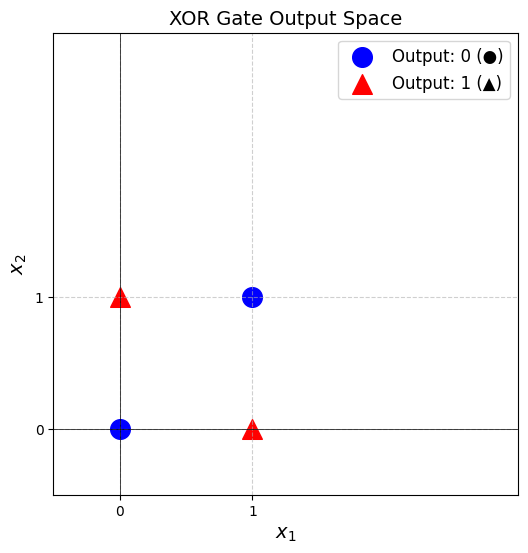

In [ ]:
import matplotlib.pyplot as plt

# 1. 4つの入力パターン (x1, x2) を定義
x1_data = np.array([0, 0, 1, 1])
x2_data = np.array([0, 1, 0, 1])

# 2. XORゲートの出力を定義 (0または1)
# (0,0)->0, (0,1)->1, (1,0)->1, (1,1)->0
y_data = np.array([0, 1, 1, 0])

# 3. グラフのプロット領域を設定
plt.figure(figsize=(6, 6))

# 4. 出力 y の値に応じてマーカーと色を分けてプロット
for x1, x2, y in zip(x1_data, x2_data, y_data):
    if y == 1:
        # 出力が1の場合は ▲ マーク (赤色)
        plt.scatter(x1, x2, marker='^', color='red', s=200, label='Output: 1 (▲)' if 'Output: 1 (▲)' not in plt.gca().get_legend_handles_labels()[1] else "")
    else:
        # 出力が0の場合は ● マーク (青色)
        plt.scatter(x1, x2, marker='o', color='blue', s=200, label='Output: 0 (●)' if 'Output: 0 (●)' not in plt.gca().get_legend_handles_labels()[1] else "")

plt.xlim(-0.5, 3.0)
plt.ylim(-0.5, 3.0)
plt.xticks([0, 1])
plt.yticks([0, 1])
plt.xlabel('$x_1$', fontsize=14)
plt.ylabel('$x_2$', fontsize=14)
plt.title('XOR Gate Output Space', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper right', fontsize=12)

plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)

# グラフを表示
plt.show()

式(2)で表されるパーセプトロンで実装するためには、$y=b + w_1 x_1 + w_2 x_2$の直線で、$x_1$-$x_2$平面上の▲(出力1)と●(出力0)を分ける必要がある。\
上図は、一本の直線で出力を分けることができない非線形な領域となっている。

###2.4.2 AND,NAND,ORゲートの出力
また、AND,NAND,ORゲートの出力を$x_1$-$x_2$平面上に表すと以下のようになる。

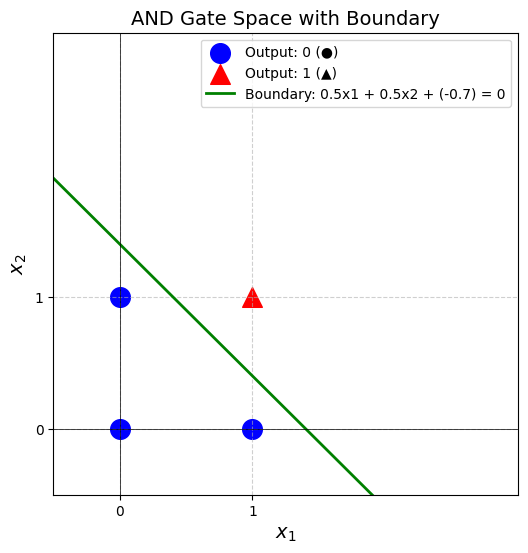

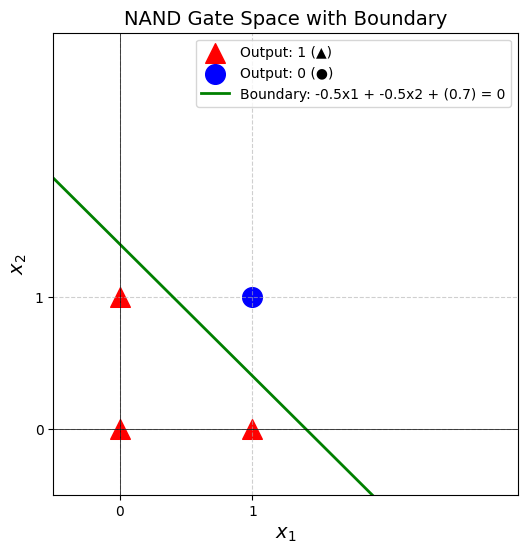

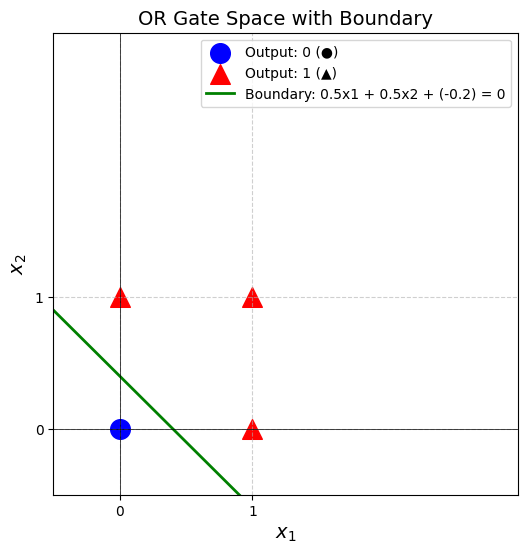

In [ ]:
def plot_gate_with_boundary(gate_function, gate_name, b, w1, w2):
    """
    ゲート関数の出力をプロットし、指定されたパラメータ(b, w1, w2)による境界線を描画する関数
    """
    # 4つの入力パターン
    x1_data = np.array([0, 0, 1, 1])
    x2_data = np.array([0, 1, 0, 1])

    # ゲート関数から動的に出力を取得して配列に格納
    y_data = np.array([gate_function(x1, x2) for x1, x2 in zip(x1_data, x2_data)])

    # グラフ領域の設定
    plt.figure(figsize=(6, 6))

    # 出力 y の値に応じてマーカーと色を分けてプロット
    for x1, x2, y in zip(x1_data, x2_data, y_data):
        if y == 1:
            plt.scatter(x1, x2, marker='^', color='red', s=200,
                        label='Output: 1 (▲)' if 'Output: 1 (▲)' not in plt.gca().get_legend_handles_labels()[1] else "")
        else:
            plt.scatter(x1, x2, marker='o', color='blue', s=200,
                        label='Output: 0 (●)' if 'Output: 0 (●)' not in plt.gca().get_legend_handles_labels()[1] else "")

    # 境界線 b + w1*x1 + w2*x2 = 0 (x2 = -w1/w2 * x1 - b/w2) の描画
    # w2 が 0 の場合は垂直な直線になるため安全に処理
    x1_line = np.linspace(-0.5, 3.0, 100)
    if w2 != 0:
        x2_line = -(w1 * x1_line + b) / w2
        plt.plot(x1_line, x2_line, color='green', linewidth=2, linestyle='-',
                 label=f'Boundary: {w1}x1 + {w2}x2 + ({b}) = 0')
    else:
        # w2 が 0 のときは x1 = -b/w1 の垂直線
        plt.axvline(x=-b/w1, color='green', linewidth=2, linestyle='-',
                    label=f'Boundary: {w1}x1 + ({b}) = 0')

    # グラフの見栄えを調整
    plt.xlim(-0.5, 3.0)
    plt.ylim(-0.5, 3.0)
    plt.xticks([0, 1])
    plt.yticks([0, 1])
    plt.xlabel('$x_1$', fontsize=14)
    plt.ylabel('$x_2$', fontsize=14)
    plt.title(f'{gate_name} Gate Space with Boundary', fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.axhline(0, color='black', linewidth=0.5)
    plt.axvline(0, color='black', linewidth=0.5)
    plt.legend(loc='upper right', fontsize=10)

    plt.show()

# --- 3. 実行例（パラメータを与えて描画） ---
# パラメータ例: b = -theta, w1 = w1, w2 = w2
# 各ゲートが綺麗に分離できる直線パラメータを引数に与えています

plot_gate_with_boundary(AND2,  "AND",  b=-0.7, w1=0.5, w2=0.5)
plot_gate_with_boundary(NAND2, "NAND", b=0.7,  w1=-0.5, w2=-0.5)
plot_gate_with_boundary(OR2,   "OR",   b=-0.2, w1=0.5, w2=0.5)

これより、AND,NAND,ORゲートでは、$x_1$-$x_2$平面上において、出力を1本の直線で分けることができていることが確認できる。

##2.5 多層パーセプトロン
単層のパーセプトロンではXORゲートは実装できなかったが、「__層を重ねる__」ことでXORゲートを表現できるようになる。

###2.5.1 XORゲートの実装
XORゲートを実装する一つの方法として、AND,NAND,ORゲートを組み合わせて配線するやり方がある。\
実際に、XORゲートは以下の図のような配線で実装できる。

このように配線したときの真理値表は、NANDゲートの出力を$s_1$、OR回路の出力を$s_2$とすると、以下のように表される。

表5 ORゲートの真理値表
| $x_1$ | $x_2$ | $s_1$ | $s_2$ | $y$ |
| :---: | :---: | :---: | :---: | :---: |
| 0 | 0 | 1 | 0 | 0 |
| 0 | 1 | 1 | 1 | 1 |
| 1 | 0 | 1 | 1 | 1 |
| 1 | 1 | 0 | 1 | 0 |

図2の配線で表されるXORゲートをPythonで実装すると以下のように表される。

In [ ]:
def XOR(x1,x2):
  s1 = NAND2(x1,x2)
  s2 = OR2(x1,x2)
  y = AND2(s1,s2)
  return y

xor_result = display_truth_table(XOR, "XOR")

--- XOR の真理値表 ---
x1 | x2 | y
---|----|---
 0 |  0 | 0
 0 |  1 | 1
 1 |  0 | 1
 1 |  1 | 0



###2.5.2 XORゲートのパーセプトロンによる確認
実装したXORゲートを、パーセプトロンの表現で表すと以下の図3のようになる。

![図3 XORゲートのパーセプトロンによる表記]()

図のようにXORゲートは多層構造のネットワークである。AND,NAND,ORゲートが単層パーセプトロンであったのに対して、XORゲートは2層のパーセプトロンとなっている。\
このような層を複数重ねたパーセプトロンを「__多層パーセプトロン__」と言う。

また、図3で表されたパーセプトロンの動作の層間での送受信は次のようになる。

1. 第0層の2つのニューロンが入力信号を受け取り、第1層のニューロンへ信号を送る。

2. 第1層のニューロンが第2層のニューロンへ信号を送り、第2層目のニューロンは$y$を出力する。

XORゲートの実装から、単層のパーセプトロンで実現できなかったことが、層をひとつ増やすことによって実現できるようになった。つまり、パーセプトロンは層を重ねることで、
より柔軟な表現が可能になると言える。

##2.6 NANDからコンピュータへ

多層のパーセプトロンは、より複雑な回路を作ることができる。ここで、NANDゲートだけで、コンピュータの処理を再現できることを考慮すれば、パーセプトロンでも、同じように表現できる。理論的には、2層のパーセプトロンがあればコンピュータを作ることができる(次章参照)。\
このように、パーセプトロンは層を重ねることで非線形な表現も可能になり、理論上はコンピュータが行うような処理も表現可能になる。


##参考文献
